## Завдання І, ІІ рівнів складності – максимально 7, 8 балів відповідно.
### Розробити програмний скрипт мовою Python що забезпечує аналіз властивостей і характеристик вихідних даних відповідно до етапів:
1. Модель генерації випадкової величини за заданим у табл.1 додатку 1 закону
розподілу;
2. Модель зміни (ідеальний тренд) досліджуваного процесу за заданим у табл.1
додатку 1 законом;
3. Адитивна модель статистичної вибірки відповідно до синтезованих в п.1,2 моделей
випадкової (стохастична) і невипадкової складових. Параметри закону розподілу та закону
зміни досліджуваного процесу обрати самостійно.
4. Визначення статистичних (числових) характеристик сформованих в п.1,3 вибірок
(дисперсія, середньоквадратичне відхилення, математичне очікування, гістограма закону
розподілу).
5. Визначення статистичних характеристик реальних даних, заданих файлом
Oschadbank (USD).xls за умов табл. 1 додатку 1.
6. Провести аналіз отриманих результатів та верифікацію розробленого скрипта.

# Завдання ІІІ рівня – максимально 10 балів.
1. Провести парсинг самостійно обраного сайту. Вміст даних, що підлягають парсингу
– обрати самостійно.
2. Результати парсингу зберегти у файлі. Тип файлу обрати самостійно.
3. Оцінити динаміку тренду реальних даних.
4. Здійснити визначення статистичних характеристик результатів парсингу.
5. Синтезувати та верифікувати модель даних, аналогічних за трендом і
статистичними характеристиками реальним даним, які є результатом парсингу.
6. Провести аналіз отриманих результатів.

P.s: *Завдання III рівня було обрано до виконання*

### 1. Провести парсинг самостійно обраного сайту. Вміст даних, що підлягають парсингу

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import json
import statsmodels.tsa.seasonal as seas
from bs4 import BeautifulSoup
from pathlib import Path

In [2]:
# Parsing the website and getting the data
url = 'https://charts.finance.ua/ua/currency/data-archive?for=interbank&source=1&indicator=eur'
response = requests.get(url)
js = json.JSONDecoder().decode(response.text)

# Turning list to DataFrame for more comfortable usage later and cutting to 2024
df = pd.DataFrame(js, columns=['Date', 'Buy', 'Sell'])
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', dayfirst=True)
df = df[(df['Date'] < '2024-12-31') & (df['Date'] > '2023-12-31')].reset_index(drop=True)
df[['Buy', 'Sell']] = df[['Buy', 'Sell']].astype(float)

js

[['03/25/1999', '4.2767', '4.3233'],
 ['03/26/1999', '4.2800', '4.3000'],
 ['03/29/1999', '4.2200', '4.3100'],
 ['03/30/1999', '4.2000', '4.2300'],
 ['03/31/1999', '4.2085', '4.2350'],
 ['04/01/1999', '4.1939', '4.2000'],
 ['04/05/1999', '4.2276', '4.2567'],
 ['04/06/1999', '4.2251', '4.2450'],
 ['04/07/1999', '4.2290', '4.2567'],
 ['04/08/1999', '4.2000', '4.2400'],
 ['04/09/1999', '4.2267', '4.2667'],
 ['04/13/1999', '4.2450', '4.2700'],
 ['04/14/1999', '4.2400', '4.2500'],
 ['04/15/1999', '4.2300', '4.2553'],
 ['04/16/1999', '4.1900', '4.2200'],
 ['04/19/1999', '4.1833', '4.2033'],
 ['04/20/1999', '4.1650', '4.1900'],
 ['04/21/1999', '4.1600', '4.1867'],
 ['04/22/1999', '4.1600', '4.1900'],
 ['04/23/1999', '4.1550', '4.1750'],
 ['04/26/1999', '4.1611', '4.1767'],
 ['04/27/1999', '4.1600', '4.1900'],
 ['04/28/1999', '4.1715', '4.1865'],
 ['04/29/1999', '4.1700', '4.1900'],
 ['04/30/1999', '4.1571', '4.1800'],
 ['05/05/1999', '4.1563', '4.1750'],
 ['05/06/1999', '4.1775', '4.2000'],
 

In [3]:
df

,Date,Buy,Sell
0,2024-01-01,42.2320,42.2499
1,2024-01-02,41.7985,41.8107
2,2024-01-03,41.6434,41.6559
3,2024-01-04,41.7846,41.8060
4,2024-01-05,41.7666,41.8175
...,...,...,...
256,2024-12-24,43.6261,43.6301
257,2024-12-25,43.5848,43.6140
258,2024-12-26,43.5449,43.5552
259,2024-12-27,43.7516,43.7703


### 2. Результати парсингу зберегти у файлі. Тип файлу обрати самостійно.

In [4]:
# Saving the results of parsing to a file(.csv format)
file_path = Path('data/Eur_Uah.csv')
file_path.parent.mkdir(parents=True, exist_ok=True)

if file_path.is_file():
    print(f'Файл "{file_path}" вже існує.')
else:
    df.to_csv(file_path, index=False)
    print(f'Файл успішно збережено до "{file_path}"')

Файл "data/Eur_Uah.csv" вже існує.


### 3. Оцінити динаміку тренду реальних даних.

In [25]:
def draw_plots(dtf, date_arg, second_arg):
    fig, ax = plt.subplots(2, 1)
    fig.set_figheight(10)
    # fig.tight_layout()

    # Common plot with basic information and EMA trend
    ax[0].set_xlabel('Графік реальних даних з накладеною EMA')
    ax[0].plot(dtf[date_arg], dtf[second_arg], color='g')
    ax[0].plot(dtf[date_arg], dtf[second_arg].ewm(span=50, adjust=False).mean(), color='b')

    # Histogram
    ax[1].hist(dtf[second_arg], bins=np.arange(round(dtf[second_arg].min()), round(dtf[second_arg].max() + 1), 0.5), edgecolor='black')
    ax[1].set_xlabel('Графік емпіричного розподілу частот')
    # dtf.hist(by=second_arg, ax=ax[1], color='g')

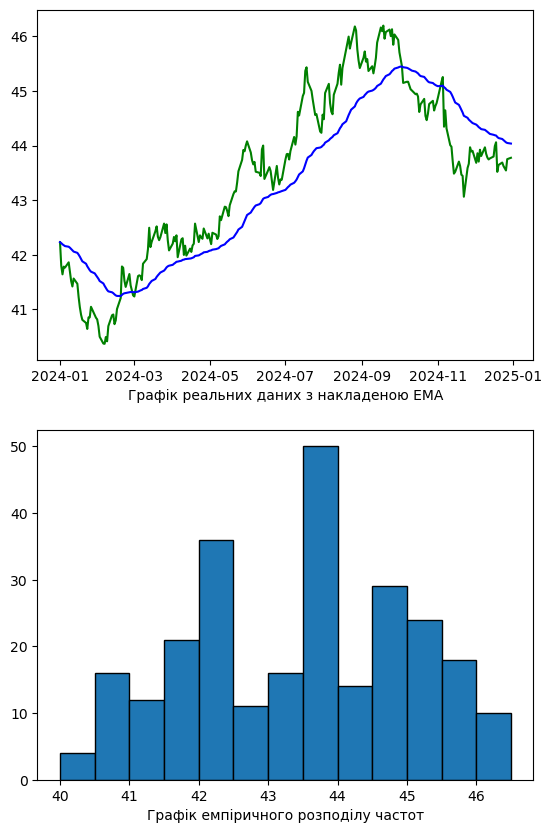

In [26]:
draw_plots(df, 'Date', 'Buy')

In [7]:
# Decomposition
df_decomposed = df.set_index('Date')
decomposition = seas.seasonal_decompose(x=df_decomposed['Buy'], period=5, model='additive')
df_decomposed = pd.concat([df_decomposed, decomposition.trend, decomposition.seasonal, decomposition.resid], axis=1)

df_decomposed

,Buy,Sell,trend,seasonal,resid
Date,,,,,
2024-01-01,42.2320,42.2499,NaN,0.056736,NaN
2024-01-02,41.7985,41.8107,NaN,0.030723,NaN
2024-01-03,41.6434,41.6559,41.84502,-0.001000,-0.200620
2024-01-04,41.7846,41.8060,41.77128,-0.050321,0.063641
2024-01-05,41.7666,41.8175,41.74880,-0.036137,0.053937
...,...,...,...,...,...
2024-12-24,43.6261,43.6301,43.61830,0.030723,-0.022923
2024-12-25,43.5848,43.6140,43.63950,-0.001000,-0.053700
2024-12-26,43.5449,43.5552,43.65688,-0.050321,-0.061659


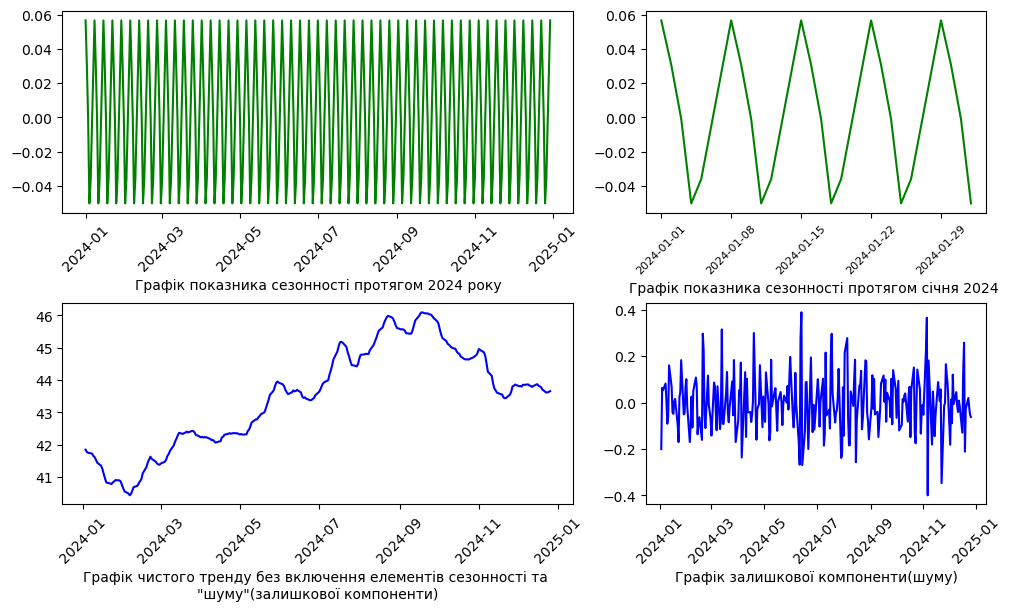

In [39]:
# Setting some additional parameters for the next plots
fig, ax = plt.subplots(2, 2, layout='constrained', width_ratios=[0.6, 0.4])
fig.set_figheight(6)
fig.set_figwidth(10)
ax[0][0].tick_params(axis='x', labelrotation=45)
ax[0][0].set_xlabel('Графік показника сезонності протягом 2024 року')
ax[0][1].set_xticks(ticks=df[::5]['Date'], labels=df[::5]['Date'].astype(str), rotation=45, size=8)
ax[0][1].set_xlabel('Графік показника сезонності протягом січня 2024 ')
ax[1][0].tick_params(axis='x', labelrotation=45)
ax[1][0].set_xlabel('Графік чистого тренду без включення елементів сезонності та \n"шуму"(залишкової компоненти)')
ax[1][1].tick_params(axis='x', labelrotation=45)
ax[1][1].set_xlabel('Графік залишкової компоненти(шуму)')
# fig.tight_layout()

ax[0][0].plot(df_decomposed['seasonal'], color='g')
ax[0][1].plot(df_decomposed['seasonal']['2024/01/01':'2024/02/01'], color='g', )
ax[1][0].plot(df_decomposed['trend'], color='b')
ax[1][1].plot(df_decomposed['resid'], color='b')
# ax[0].plot(dtf[date_arg], dtf[second_arg].ewm(span=50, adjust=False).mean(), color='b')

### 3.5 Визначення аномальних вимірів та нормалізація отриманих результатів

In [ ]:
# TODO: Написати код для різних типів визначення АВ


In [ ]:
# TODO: Написати код для усунення АВ або їх трансформацію у підходящий формат


### 4. Здійснити визначення статистичних характеристик результатів парсингу.

In [ ]:
# TODO: Написати код для базових стат. характ. + визначити коефіцієнти поліному + порівняти їх з тими, які можна отримати з попередньо отриманої трендової складової за допомогою функції statsmodels

### 5. Синтезувати та верифікувати модель даних, аналогічних за трендом і статистичними характеристиками реальним даним, які є результатом парсингу.

In [ ]:
# TODO: Синтезувати модель за допомогою МНК + додати якийсь графік з результатами

### 5.5 Виконати екстраполяцію та інтерполяцію моделі

In [ ]:
# TODO: Побудувати алгоритм для цієї хріні